# Machine Learning-Based Prediction of Tourist Arrivals: Final Split Comparison

### ET-3043 Machine Learning Final Assignment

**Problem type:** Regression  
**Target variable:** `totalCount`  
**Models used:** Linear Regression, Polynomial Regression, and Support Vector Regression (SVR)

**Evaluation strategies:** Chronological future-year split and randomized row split  

## 1. Project Overview

This notebook predicts monthly tourist arrivals to Sri Lanka by origin country using economic, environmental, and tourism-related factors. The work follows the assignment requirements for a regression problem: data preparation, exploratory data analysis, model training, validation/testing, and evaluation using MAE, MSE, RMSE, and R2 Score.

## 2. Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

# Save publication-ready copies while still displaying figures in the notebook.
FIGURE_DIR = Path("paper/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## 3. Load and Understand the Dataset

In [2]:
df = pd.read_csv("touristData.csv")

df.head()

,year,month,originCountry,totalCount,dollarRate,apparent_temperature_mean_celcius,sunshine_duration_seconds,rain_sum_mm,precipitation_hours,num_establishments,num_rooms,AirPassengerFaresIndex,consumerPriceIndex
0,2024,January,India,34399,315.7,30.787654,33462.04969,7.67284,7.012346,4519,55455,178.0,185.5
1,2024,January,Russia,31159,315.7,30.787654,33462.04969,7.67284,7.012346,4519,55455,178.0,251.3
2,2024,January,United Kingdom,16665,315.7,30.787654,33462.04969,7.67284,7.012346,4519,55455,178.0,130.0
3,2024,January,Germany,13593,315.7,30.787654,33462.04969,7.67284,7.012346,4519,55455,178.0,117.6
4,2024,January,China,11511,315.7,30.787654,33462.04969,7.67284,7.012346,4519,55455,178.0,103.1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   year                               750 non-null    int64  
 1   month                              750 non-null    object 
 2   originCountry                      750 non-null    object 
 3   totalCount                         750 non-null    int64  
 4   dollarRate                         750 non-null    float64
 5   apparent_temperature_mean_celcius  750 non-null    float64
 6   sunshine_duration_seconds          750 non-null    float64
 7   rain_sum_mm                        750 non-null    float64
 8   precipitation_hours                750 non-null    float64
 9   num_establishments                 750 non-null    int64  
 10  num_rooms                          750 non-null    int64  
 11  AirPassengerFaresIndex             750 non-null    float64

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 750
Columns: 13


In [5]:
df.describe()

,year,totalCount,dollarRate,apparent_temperature_mean_celcius,sunshine_duration_seconds,rain_sum_mm,precipitation_hours,num_establishments,num_rooms,AirPassengerFaresIndex,consumerPriceIndex
count,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000
mean,2021.120000,8621.441333,246.605333,29.279963,33570.295600,6.008511,7.797062,3495.320000,46494.480000,174.862667,134.335778
std,2.086001,9127.986128,74.757200,0.669481,2278.424351,2.004730,1.349833,860.378253,6854.116363,13.358923,42.809533
min,2018.000000,10.000000,153.900000,28.228086,28159.767720,2.075309,4.222222,2121.000000,35397.000000,140.800000,73.235850
25%,2019.000000,2613.500000,179.900000,28.723765,31987.295150,4.783333,6.651235,2620.000000,40365.000000,167.600000,104.305000
50%,2021.000000,5700.000000,200.920000,29.189506,33666.409040,6.179630,7.910494,3656.000000,47337.000000,177.000000,118.515000
75%,2023.000000,10807.500000,317.000000,29.616358,35063.090900,7.485494,8.796296,4346.000000,53229.000000,184.200000,143.998760
max,2024.000000,52881.000000,368.500000,30.940741,38963.963890,10.306481,10.845679,4519.000000,55455.000000,202.900000,331.870000


In [6]:
data_quality = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Data Type": df.dtypes
})

data_quality

,Missing Values,Data Type
year,0,int64
month,0,object
originCountry,0,object
totalCount,0,int64
dollarRate,0,float64
apparent_temperature_mean_celcius,0,float64
sunshine_duration_seconds,0,float64
rain_sum_mm,0,float64
precipitation_hours,0,float64
num_establishments,0,int64


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 4. Exploratory Data Analysis

These plots summarize the target distribution, time trend, country contribution, monthly seasonality, and numeric feature relationships.

In [8]:
month_order = [
    'January', 'February', 'March',
    'April', 'May', 'June',
    'July', 'August', 'September',
    'October', 'November', 'December'
]

month_mapping = {
    month: index
    for index, month in enumerate(month_order, start=1)
}


df['date'] = pd.to_datetime(
    df['year'].astype(str) + '-' + df['month'] + '-01'
)

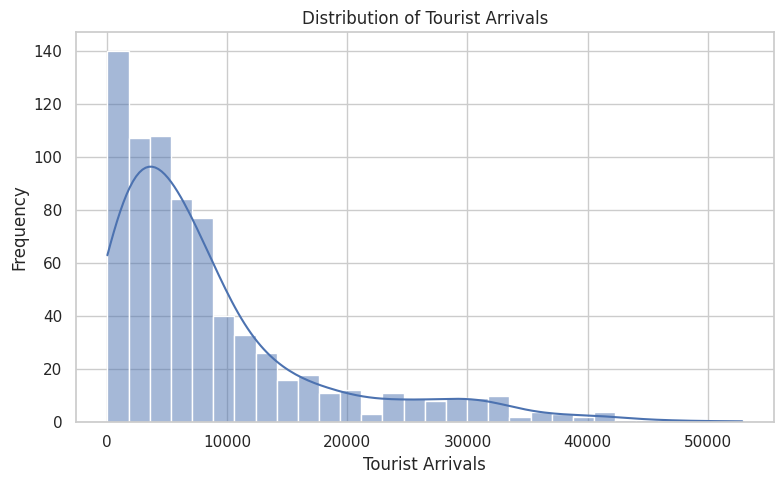

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df['totalCount'],
    bins=30,
    kde=True
)

plt.title("Distribution of Tourist Arrivals")
plt.xlabel("Tourist Arrivals")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "target_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

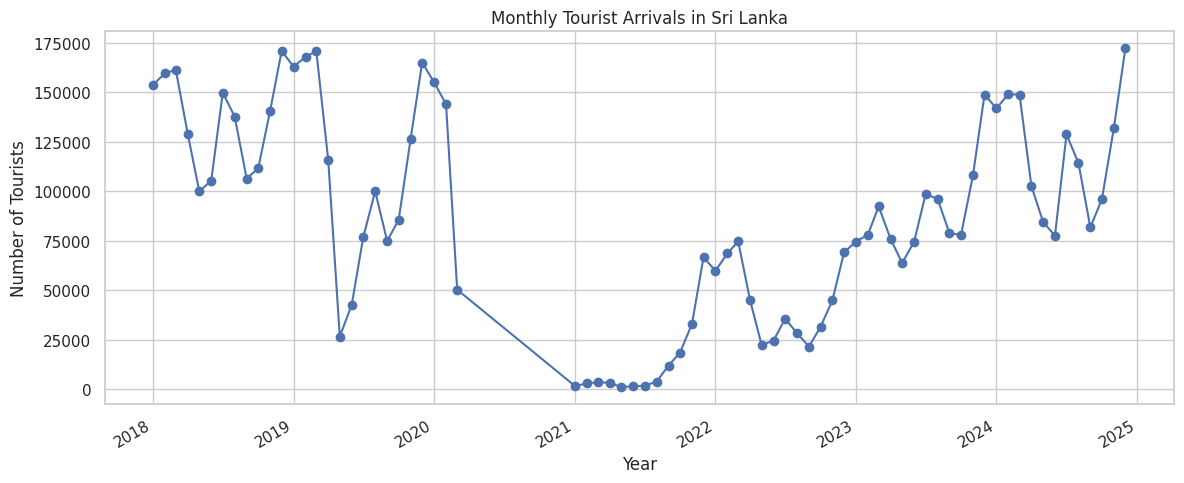

In [10]:
monthly_total = df.groupby('date')['totalCount'].sum()

plt.figure(figsize=(12, 5))
monthly_total.plot(marker='o')

plt.title("Monthly Tourist Arrivals in Sri Lanka")
plt.xlabel("Year")
plt.ylabel("Number of Tourists")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "monthly_arrivals_timeline.png", dpi=300, bbox_inches="tight")

plt.show()

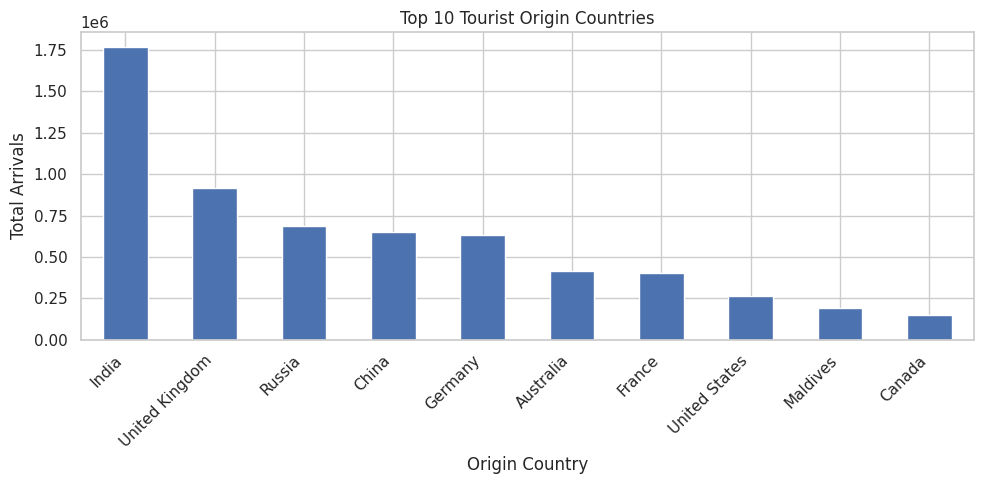

In [11]:
country_total = (
    df.groupby('originCountry')['totalCount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
country_total.plot(kind='bar')

plt.title("Top 10 Tourist Origin Countries")
plt.xlabel("Origin Country")
plt.ylabel("Total Arrivals")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURE_DIR / "top_origin_countries.png", dpi=300, bbox_inches="tight")

plt.show()

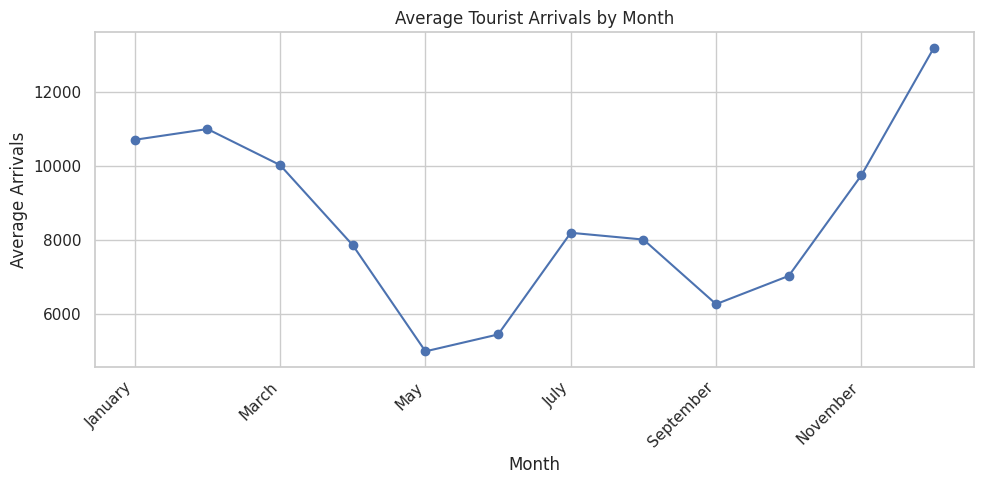

In [12]:
monthly_pattern = (
    df.groupby('month')['totalCount']
    .mean()
    .reindex(month_order)
)

plt.figure(figsize=(10, 5))
monthly_pattern.plot(marker='o')

plt.title("Average Tourist Arrivals by Month")
plt.xlabel("Month")
plt.ylabel("Average Arrivals")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "average_arrivals_by_month.png", dpi=300, bbox_inches="tight")

plt.show()

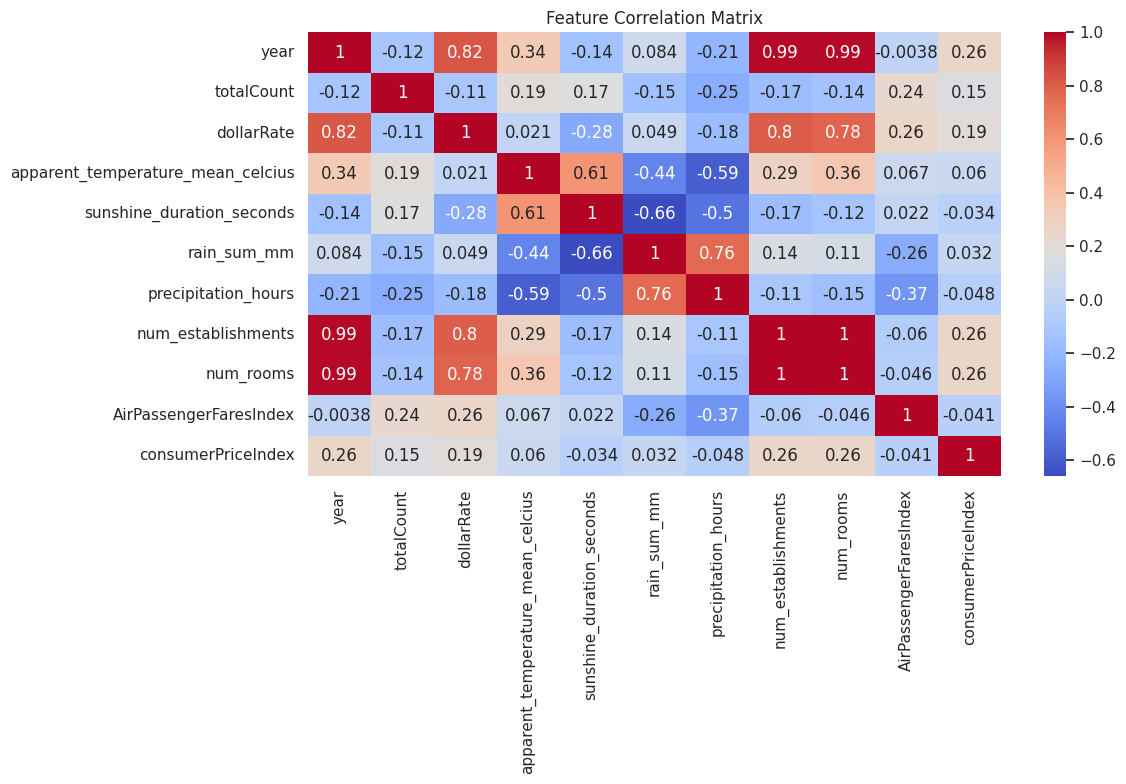

In [13]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "feature_correlation_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

### Additional EDA: Relationship with the target variable

The previous plots show the overall trend, but the assignment also benefits from a direct review of which features are most closely associated with tourist arrivals.

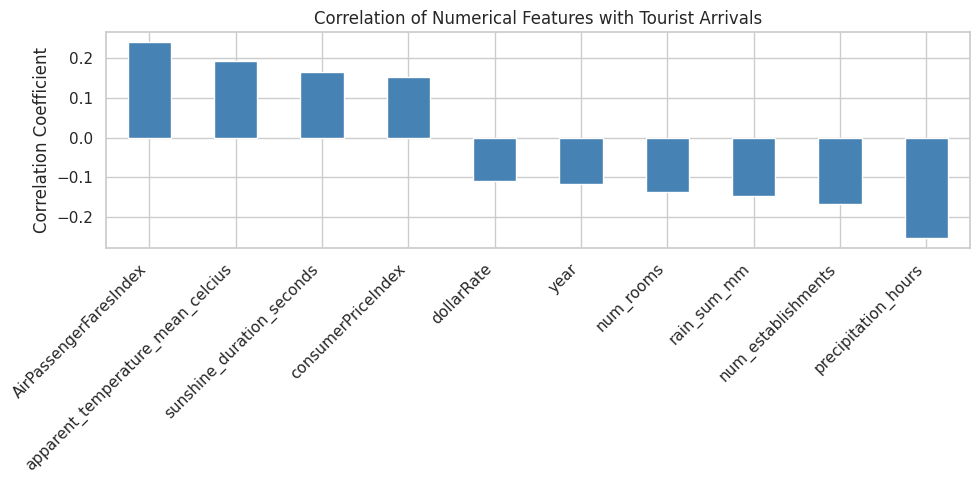

AirPassengerFaresIndex               0.241346
apparent_temperature_mean_celcius    0.194328
sunshine_duration_seconds            0.165637
consumerPriceIndex                   0.153506
dollarRate                          -0.111067
year                                -0.118207
num_rooms                           -0.137467
rain_sum_mm                         -0.147451
num_establishments                  -0.166978
precipitation_hours                 -0.254570
dtype: float64

In [14]:
numeric_features_for_corr = [
    col for col in df.select_dtypes(include=np.number).columns
    if col != 'totalCount'
]

feature_target_corr = (
    df[numeric_features_for_corr]
    .corrwith(df['totalCount'])
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
feature_target_corr.plot(kind='bar', color='steelblue')
plt.title('Correlation of Numerical Features with Tourist Arrivals')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'target_feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

feature_target_corr

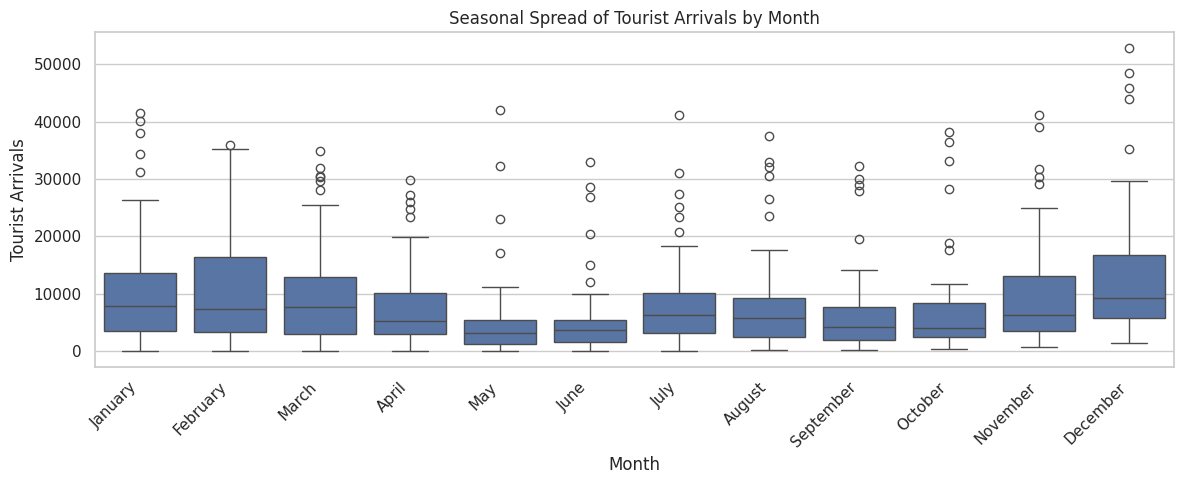

In [15]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='month', y='totalCount', order=month_order)
plt.title('Seasonal Spread of Tourist Arrivals by Month')
plt.xlabel('Month')
plt.ylabel('Tourist Arrivals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'monthly_arrivals_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Feature Preparation

The target variable is `totalCount`. The `date` column is used only for time-based splitting and visualization, so it is removed from model features. `month` and `originCountry` are categorical for Linear Regression. For Polynomial Regression, a second-degree polynomial term is applied only to `month` to avoid creating too many unstable polynomial interactions.

In [16]:
corr_matrix = df.select_dtypes(include=np.number).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
df_reduced = df.drop(to_drop, axis=1)

In [17]:
X = df.drop(
    columns=['totalCount', 'date']
)

y = df['totalCount']

# Convert month names to ordered month numbers for model input.
X['month'] = X['month'].map(month_mapping)

In [18]:
categorical_features = [
    'month',
    'originCountry'
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['year', 'dollarRate', 'apparent_temperature_mean_celcius', 'sunshine_duration_seconds', 'rain_sum_mm', 'precipitation_hours', 'num_establishments', 'num_rooms', 'AirPassengerFaresIndex', 'consumerPriceIndex']
Categorical features: ['month', 'originCountry']


In [19]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        )
    ]
)


polynomial_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            [
                col for col in X.columns
                if col not in ['month', 'originCountry']
            ]
        ),
        (
            'month_poly',
            Pipeline(
                steps=[
                    ('scaler', StandardScaler()),
                    ('polynomial_features', PolynomialFeatures(
                        degree=2,
                        include_bias=False
                    ))
                ]
            ),
            ['month']
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            ['originCountry']
        )
    ]
)

## 6. Training, Validation, and Testing Split

Because the dataset is time-based, a chronological split is used instead of random splitting. This prevents future information from leaking into model training.

,Split,Years,Rows
0,Train,2018-2022,510
1,Validation,2023,120
2,Test,2024,120


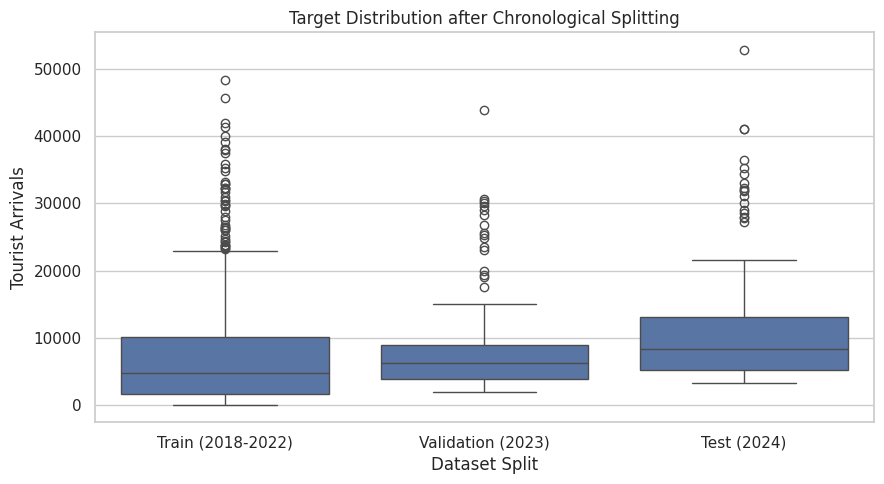

In [20]:
train = df[df.year <= 2022].copy()
validation = df[df.year == 2023].copy()
test = df[df.year == 2024].copy()

X_train = X.loc[train.index].copy()
y_train = train['totalCount']

X_val = X.loc[validation.index].copy()
y_val = validation['totalCount']

X_test = X.loc[test.index].copy()
y_test = test['totalCount']

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Years": [
        f"{train.year.min()}-{train.year.max()}",
        str(validation.year.unique()[0]),
        str(test.year.unique()[0])
    ],
    "Rows": [len(train), len(validation), len(test)]
})

display(split_summary)

# Visualize the target distribution produced by chronological preprocessing.
split_target_data = pd.concat([
    pd.DataFrame({'Split': 'Train (2018-2022)', 'Tourist Arrivals': y_train}),
    pd.DataFrame({'Split': 'Validation (2023)', 'Tourist Arrivals': y_val}),
    pd.DataFrame({'Split': 'Test (2024)', 'Tourist Arrivals': y_test})
])

plt.figure(figsize=(9, 5))
sns.boxplot(data=split_target_data, x='Split', y='Tourist Arrivals')
plt.title('Target Distribution after Chronological Splitting')
plt.xlabel('Dataset Split')
plt.ylabel('Tourist Arrivals')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'chronological_split_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Model Training

Three regression models are used: Linear Regression, Polynomial Regression, and Support Vector Regression (SVR). SVR uses an RBF kernel to model nonlinear relationships.

In [21]:
linear_model = Pipeline(
    steps=[
        ('preprocessor', linear_preprocessor),
        ('model', LinearRegression())
    ]
)


polynomial_model = Pipeline(
    steps=[
        ('preprocessor', polynomial_preprocessor),
        ('model', LinearRegression())
    ]
)


svm_model = Pipeline(
    steps=[
        ('preprocessor', linear_preprocessor),
        ('model', TransformedTargetRegressor(
            regressor=SVR(kernel='rbf', C=10, epsilon=0.1),
            transformer=StandardScaler()
        ))
    ]
)


models = {
    "Linear Regression": linear_model,
    "Polynomial Regression": polynomial_model,
    "Support Vector Regression": svm_model
}

## 8. Performance Evaluation

For this regression problem, the assignment requires MAE, MSE, RMSE, and R2 Score.

In [22]:
def evaluate_model(model, X_eval, y_eval):
    predictions = model.predict(X_eval)

    mae = mean_absolute_error(y_eval, predictions)
    mse = mean_squared_error(y_eval, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_eval, predictions)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

In [23]:
rows = []

for name, model in models.items():
    model.fit(X_train, y_train)

    for split_name, X_eval, y_eval in [
        ('Validation 2023', X_val, y_val),
        ('Test 2024', X_test, y_test)
    ]:
        score = evaluate_model(model, X_eval, y_eval)
        score['Model'] = name
        score['Split'] = split_name
        rows.append(score)


results = (
    pd.DataFrame(rows)
    .set_index(['Model', 'Split'])
    .sort_values('RMSE')
)

results

MAE           MSE  \
Model                     Split                                        
Linear Regression         Test 2024        5011.122891  4.528132e+07   
                          Validation 2023  4819.646244  4.684364e+07   
Polynomial Regression     Test 2024        4786.241818  5.196211e+07   
                          Validation 2023  5998.047320  6.242912e+07   
Support Vector Regression Validation 2023  5564.247857  7.242323e+07   
                          Test 2024        7769.735724  1.466772e+08   

                                                   RMSE  R2 Score  
Model                     Split                                    
Linear Regression         Test 2024         6729.139591  0.546120  
                          Validation 2023   6844.241100  0.255830  
Polynomial Regression     Test 2024         7208.475075  0.479155  
                          Validation 2023   7901.210305  0.008235  
Support Vector Regression Validation 2023   8510.184108 -0.150534  
                          Test 2024        12111.035018 -0.470227

## 9. Model Comparison and Error Analysis

The evaluation table above is useful, but a stronger report should also compare feature choices and inspect the prediction errors directly.


In [30]:
# Select numerical features directly from the correlation table above.
# The threshold is applied to absolute correlation so both positive and
# negative relationships with tourist arrivals are considered.
correlation_threshold = 0.15
selected_numeric_features = feature_target_corr[
    feature_target_corr.abs() >= correlation_threshold
].index.tolist()

reduced_feature_subset = [
    'month',
    'originCountry',
    *selected_numeric_features
]

print(f'Absolute-correlation threshold: {correlation_threshold}')
print(f'Selected numerical features: {selected_numeric_features}')
print(f'Total reduced features: {len(reduced_feature_subset)}')

X_reduced = X[reduced_feature_subset].copy()

feature_comparison_rows = []

for feature_label, X_subset in [
    ('Full features', X),
    ('Reduced features', X_reduced)
]:
    categorical_features = ['month', 'originCountry']
    numerical_features = [col for col in X_subset.columns if col not in categorical_features]

    feature_preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ]
    )

    feature_model = Pipeline(
        steps=[
            ('preprocessor', feature_preprocessor),
            ('model', LinearRegression())
        ]
    )

    feature_model.fit(X_train, y_train)

    for split_name, X_eval, y_eval in [
        ('Validation 2023', X_val, y_val),
        ('Test 2024', X_test, y_test)
    ]:
        score = evaluate_model(feature_model, X_eval, y_eval)
        score['Feature Set'] = feature_label
        score['Split'] = split_name
        feature_comparison_rows.append(score)

feature_comparison_results = (
    pd.DataFrame(feature_comparison_rows)
    .set_index(['Feature Set', 'Split'])
    .sort_values(['Split', 'RMSE'])
)

feature_comparison_results


Absolute-correlation threshold: 0.15
Selected numerical features: ['AirPassengerFaresIndex', 'apparent_temperature_mean_celcius', 'sunshine_duration_seconds', 'consumerPriceIndex', 'num_establishments', 'precipitation_hours']
Total reduced features: 8


,,MAE,MSE,RMSE,R2 Score
Feature Set,Split,,,,
Full features,Test 2024,5011.122891,4.528132e+07,6729.139591,0.546120
Reduced features,Test 2024,10170.563117,1.426606e+08,11944.061401,-0.429966
Full features,Validation 2023,4819.646244,4.684364e+07,6844.241100,0.255830
Reduced features,Validation 2023,7178.958707,7.871424e+07,8872.104626,-0.250475


## 9. Actual vs Predicted Visualization

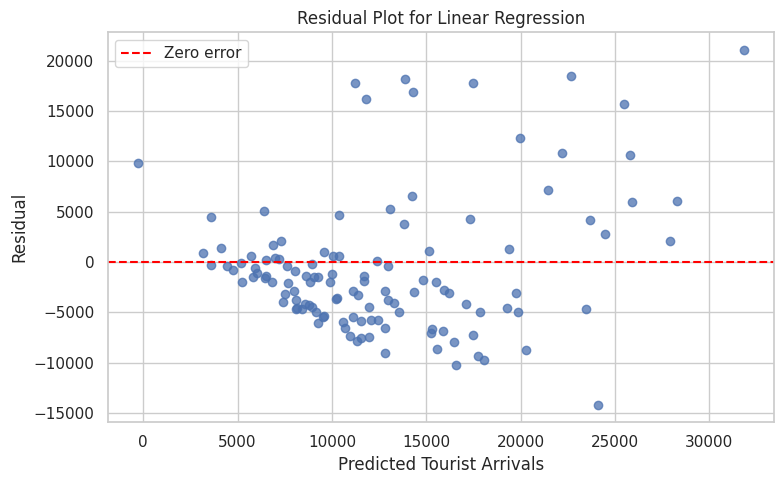

,Actual,Predicted,Residual
0,34399,28307.338152,6091.661848
1,31159,14308.694041,16850.305959
2,16665,19776.216303,-3111.216303
3,13593,15534.081720,-1941.081720
4,11511,20256.777244,-8745.777244


In [25]:
best_model_name = results.xs('Test 2024', level='Split')['RMSE'].idxmin()
best_model = models[best_model_name]
best_predictions = best_model.predict(X_test)

residuals = pd.DataFrame({
    'Actual': y_test,
    'Predicted': best_predictions,
    'Residual': y_test - best_predictions
})

plt.figure(figsize=(8, 5))
plt.scatter(
    residuals['Predicted'],
    residuals['Residual'],
    alpha=0.75
)
plt.axhline(0, color='red', linestyle='--', label='Zero error')
plt.xlabel('Predicted Tourist Arrivals')
plt.ylabel('Residual')
plt.title(f'Residual Plot for {best_model_name}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'best_model_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

residuals.head()


## 10. Results Analysis Notes

Use the evaluation table, residual plot, and the additional EDA above in the IEEE paper discussion. The new correlation analysis shows that the strongest numerical relationships with tourist arrivals are linked to economic and seasonal variables, while the monthly boxplot confirms that tourism demand varies substantially across the year. Compare Linear Regression, Polynomial Regression, and Support Vector Regression using the validation and 2024 test metrics before identifying the best-performing model.

The relatively poor R² values under chronological evaluation are largely explained by a COVID-related temporal distribution shift. The training period contains pre-pandemic tourism patterns, the sharp collapse in arrivals during 2020 and 2021, and only the beginning of recovery in 2022. In contrast, the 2023 validation set and 2024 test set represent a stronger and gradually changing recovery pattern. Consequently, the relationships between year, economic conditions, seasonal factors, and tourist arrivals are not stable across the three splits. The models learn a mixture of substantially different patterns from the training data and must then predict validation and test observations generated under a new recovery pattern, resulting in larger errors and lower—or sometimes negative—R² values.

Key points to mention in the final report:
- The dataset is clean, complete, and suitable for regression analysis.
- The EDA confirms strong seasonal and economic patterns in arrivals.
- COVID-19 caused a structural break, making the chronological training, validation, and test distributions different.
- Linear Regression provides a simple and interpretable baseline.
- Polynomial Regression and SVR provide nonlinear alternatives to the linear baseline.
- The best model should be selected from the test results rather than assumed in advance.

## 11. Execution Instructions

Run the notebook from top to bottom in a Python environment with pandas, numpy, matplotlib, seaborn, and scikit-learn installed. The file `touristData.csv` must be in the same folder as this notebook.

## 12. Randomized Train, Validation, and Test Experiment

The preceding sections use the recommended chronological split: training through 2022, validation on 2023, and testing on 2024. This additional experiment randomly assigns individual observations using a reproducible 70/15/15 split. The same preprocessing and models are used, allowing the effect of the split strategy to be examined directly.

**Important:** random splitting measures interpolation among observations from the same historical period. Because country rows from the same month and year share economic, tourism, and weather features, its results may be optimistic and should not replace chronological results when making future-forecasting claims.

In [26]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split

chronological_results = results.copy()

X_random_train, X_random_remaining, y_random_train, y_random_remaining = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_random_val, X_random_test, y_random_val, y_random_test = train_test_split(
    X_random_remaining,
    y_random_remaining,
    test_size=0.50,
    random_state=42
)

random_split_summary = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Rows': [len(X_random_train), len(X_random_val), len(X_random_test)],
    'Percentage': np.array([
        len(X_random_train), len(X_random_val), len(X_random_test)
    ]) / len(X) * 100,
    'Minimum Year': [
        X_random_train.year.min(), X_random_val.year.min(), X_random_test.year.min()
    ],
    'Maximum Year': [
        X_random_train.year.max(), X_random_val.year.max(), X_random_test.year.max()
    ]
})

random_split_summary

,Split,Rows,Percentage,Minimum Year,Maximum Year
0,Train,525,70.000000,2018,2024
1,Validation,112,14.933333,2018,2024
2,Test,113,15.066667,2018,2024


## 13. Random-Split Model Evaluation

Cloning creates fresh versions of the three model pipelines, ensuring that models fitted during chronological evaluation are not overwritten.

In [27]:
random_models = {name: clone(model) for name, model in models.items()}
random_rows = []

for name, model in random_models.items():
    model.fit(X_random_train, y_random_train)

    for split_name, X_eval, y_eval in [
        ('Random Validation', X_random_val, y_random_val),
        ('Random Test', X_random_test, y_random_test)
    ]:
        score = evaluate_model(model, X_eval, y_eval)
        score['Model'] = name
        score['Split'] = split_name
        random_rows.append(score)

random_results = (
    pd.DataFrame(random_rows)
    .set_index(['Model', 'Split'])
    .sort_values(['Split', 'RMSE'])
)

random_results

,,MAE,MSE,RMSE,R2 Score
Model,Split,,,,
Support Vector Regression,Random Test,2901.559313,1.652153e+07,4064.667922,0.834687
Linear Regression,Random Test,3950.716593,3.042679e+07,5516.048050,0.695552
Polynomial Regression,Random Test,4272.560328,3.468169e+07,5889.116273,0.652978
Support Vector Regression,Random Validation,2887.231863,1.913934e+07,4374.853012,0.818152
Linear Regression,Random Validation,3893.738023,2.936184e+07,5418.656696,0.721026
Polynomial Regression,Random Validation,4128.260471,3.167440e+07,5628.001508,0.699053


## 14. Chronological vs Random Test Comparison

This table places the two test strategies side by side. Differences quantify how much easier it is to predict randomly held-out historical rows than an entirely future year. Chronological performance is poorer because COVID-19 caused tourist arrivals to collapse and then recover gradually under a different pattern. Training therefore contains pre-pandemic, pandemic, and early-recovery behavior, whereas validation and testing primarily contain later-recovery behavior. Random splitting mixes these periods across all subsets, making their distributions more similar and usually producing a higher but more optimistic R².

In [28]:
chronological_test = chronological_results.xs('Test 2024', level='Split').copy()
chronological_test['Evaluation Strategy'] = 'Chronological Test 2024'

random_test = random_results.xs('Random Test', level='Split').copy()
random_test['Evaluation Strategy'] = 'Random Test'

split_comparison = (
    pd.concat([chronological_test, random_test])
    .reset_index()
    .set_index(['Model', 'Evaluation Strategy'])
    .sort_values(['Model', 'RMSE'])
)

split_comparison

MAE           MSE  \
Model                     Evaluation Strategy                                  
Linear Regression         Random Test              3950.716593  3.042679e+07   
                          Chronological Test 2024  5011.122891  4.528132e+07   
Polynomial Regression     Random Test              4272.560328  3.468169e+07   
                          Chronological Test 2024  4786.241818  5.196211e+07   
Support Vector Regression Random Test              2901.559313  1.652153e+07   
                          Chronological Test 2024  7769.735724  1.466772e+08   

                                                           RMSE  R2 Score  
Model                     Evaluation Strategy                              
Linear Regression         Random Test               5516.048050  0.695552  
                          Chronological Test 2024   6729.139591  0.546120  
Polynomial Regression     Random Test               5889.116273  0.652978  
                          Chronological Test 2024   7208.475075  0.479155  
Support Vector Regression Random Test               4064.667922  0.834687  
                          Chronological Test 2024  12111.035018 -0.470227

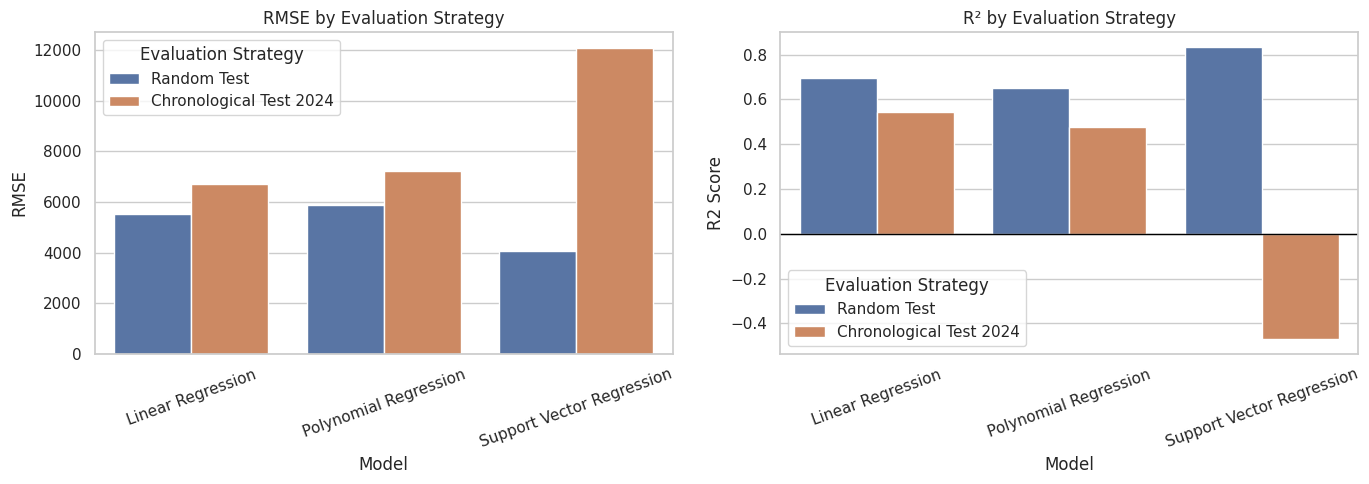

In [29]:
comparison_plot = split_comparison.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    data=comparison_plot,
    x='Model', y='RMSE', hue='Evaluation Strategy', ax=axes[0]
)
axes[0].set_title('RMSE by Evaluation Strategy')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(
    data=comparison_plot,
    x='Model', y='R2 Score', hue='Evaluation Strategy', ax=axes[1]
)
axes[1].set_title('R² by Evaluation Strategy')
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'split_strategy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 15. Final Interpretation Guidance

- Use the **chronological 2024 test metrics** as the primary evidence for future forecasting performance.
- Use the **random test metrics** as a secondary experiment showing performance when training and test observations come from the same historical distribution.
- A large improvement under random splitting is evidence of temporal distribution shift or shared month-year information, not necessarily a better forecasting model.
- The chronological R² is lower because COVID-19 produced a sharp collapse followed by gradual recovery, so the training, validation, and test sets follow substantially different tourism patterns.
- Choose models using validation performance rather than selecting the lowest 2024 test error.
- Report the split method beside every metric so readers do not confuse interpolation with future-year forecasting.
- Treat advanced-model improvements as credible forecasting gains only when they also appear on the chronological 2024 test set.